# S-Fig 26 — Hard Subjects (maybe)

Fraction of subjects correctly predicted at 0, 1, …, N context lengths.  
**Source**: collected parquets  
**Tasks**: main tasks

In [1]:
%matplotlib inline

In [2]:
import sys
from pathlib import Path

# ── Workspace root: auto-detect by looking for final_results/ ─────────────────
def _find_workspace():
    """Walk up from CWD until we find a directory containing final_results/."""
    candidate = Path.cwd().resolve()
    for _ in range(10):
        if (candidate / "final_results").exists():
            return candidate
        if candidate.parent == candidate:
            break
        candidate = candidate.parent
    # Explicit fallback (edit this if auto-detect fails)
    return Path("/Users/boshra/NSRR-workspace").resolve()

WORKSPACE_ROOT = _find_workspace()
NSRR_TOOLS     = WORKSPACE_ROOT / "NSRR-tools"
FINAL_RESULTS  = WORKSPACE_ROOT / "final_results"
PAPER_FIGURES  = NSRR_TOOLS / "results" / "paper_figures"
FINAL_OUT      = PAPER_FIGURES / "final_npj"
FINAL_OUT.mkdir(parents=True, exist_ok=True)

# Add utils to path (notebooks/utils/)
_nb_dir = PAPER_FIGURES / "notebooks_npj"
sys.path.insert(0, str(_nb_dir))

from utils.style import (
    apply_tbme_style, save_figure, FULL_W, HALF_W,
    MAIN_TASKS, SUPP_TASKS, ALL_TASKS, BINARY_MAIN,
    HEAD_STYLE, TASK_LABEL, FONT_ANNOT, FONT_BASE, FONT_LABEL, FONT_TITLE,
)
from utils.data import set_root, load_analysis, load_heatmap, load_parquets
from utils import panels

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

set_root(WORKSPACE_ROOT)
apply_tbme_style()

# ── Confirm the workspace root is correct ─────────────────────────────────────
_ok = (WORKSPACE_ROOT / "final_results").exists()
print(f"WORKSPACE_ROOT : {WORKSPACE_ROOT}")
print(f"final_results/ : {'✓ found' if _ok else '✗ NOT FOUND — edit _find_workspace() fallback'}")

WORKSPACE_ROOT : /Users/boshra/NSRR-workspace
final_results/ : ✓ found


In [3]:
# Panel labeling helper
def add_panel_label(ax, label, x=0.02, y=0.97):
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=8, fontweight="bold", va="top", fontfamily="serif")

In [4]:
HEAD   = "transformer"
SPLIT  = "test"
TASKS  = MAIN_TASKS
N_COLS = 3
N_ROWS = (len(TASKS) + N_COLS - 1) // N_COLS

pqs = {t: load_parquets("phase0_v3", t, HEAD, SPLIT) for t in TASKS}

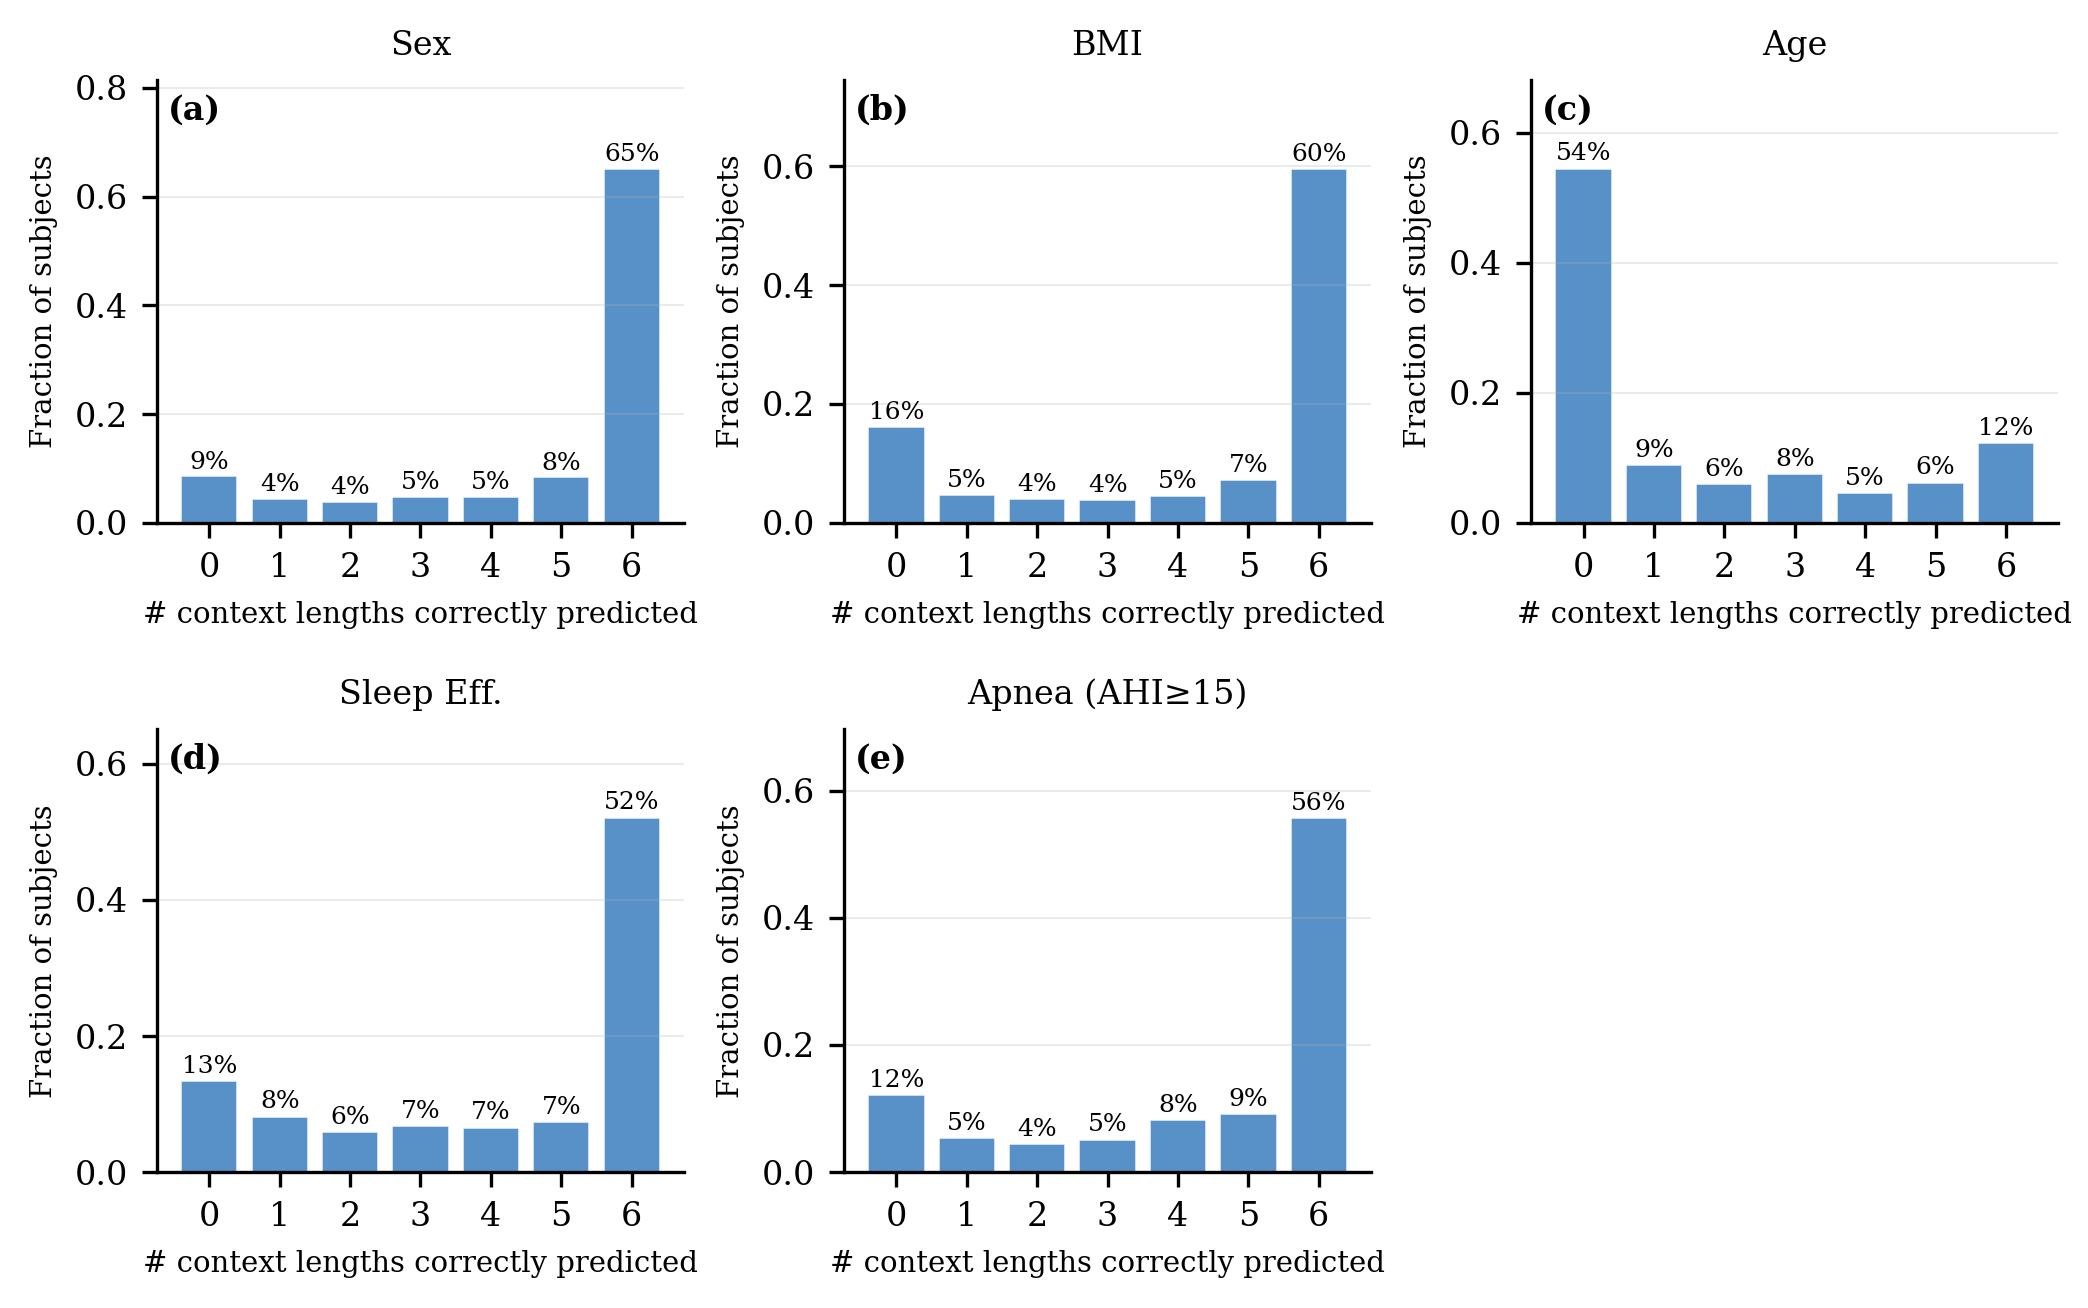

In [5]:
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(FULL_W, N_ROWS * 2.2))
axes_flat = axes.flatten()

for i, (ax, task) in enumerate(zip(axes_flat, TASKS)):
    panels.hard_subjects_panel(ax, pqs[task])
    ax.set_title(TASK_LABEL.get(task, task), fontsize=FONT_TITLE)
    add_panel_label(ax, f"({chr(97+i)})")

for ax in axes_flat[len(TASKS):]:
    ax.set_visible(False)

fig.tight_layout(h_pad=1.5, w_pad=1.0)
plt.show()

In [ ]:
# ── Run when figure looks good ──────────────────────────────
save_figure(fig, FINAL_OUT, "sfig26_hard_subjects")
import shutil
shutil.copy(FINAL_OUT / "sfig26_hard_subjects.pdf",
            WORKSPACE_ROOT / "npj_digital_medicine_submission" / "sfig26_hard_subjects.pdf")
print("Saved + copied → npj_digital_medicine_submission/sfig26_hard_subjects.pdf")

  saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/final/sfig11_hard_subjects.pdf
Saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/final/sfig11_hard_subjects.pdf
